Analizar datos y encontrar patrones.

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/dataset_limpio.csv")
df.head()


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39.0,Estándar,805.8,Brasil,Crime,2025-03-04,99
1,10001,37.0,Estándar,1173.4,Colombia,Crime,2019-04-02,2
2,10002,28.0,Básico,401.0,Colombia,Crime,2018-04-13,0
3,10003,43.0,Básico,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51.0,Básico,477.8,Perú,Thriller,2020-09-30,1


Se carga el dataset procesado luego de la etapa de limpieza. Este dataset no contiene duplicados, los valores nulos fueron tratados previamente y todas las inconcistencias previas .

emepezaos con los analisis y graficos 

 ANALISIS UNIVARIADO

EDAD

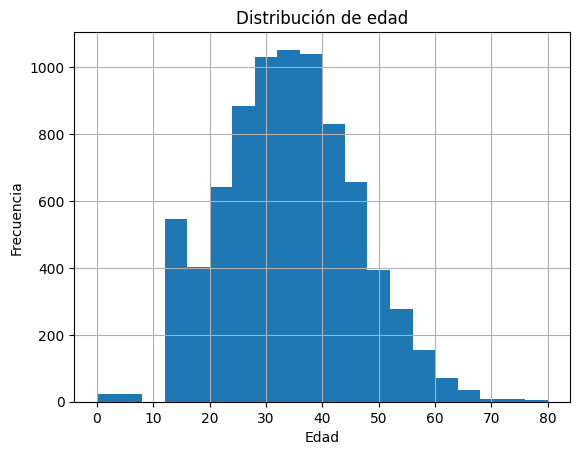

In [7]:
import matplotlib.pyplot as plt

df["age"].hist(bins=20)
plt.title("Distribución de edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

La variable edad presenta una distribución que permite identificar la concentración de usuarios en determinados rangos etarios, evidenciando la predominancia de ciertos grupos de edad dentro de la plataforma.

PLANES DE SUSCRIPCION

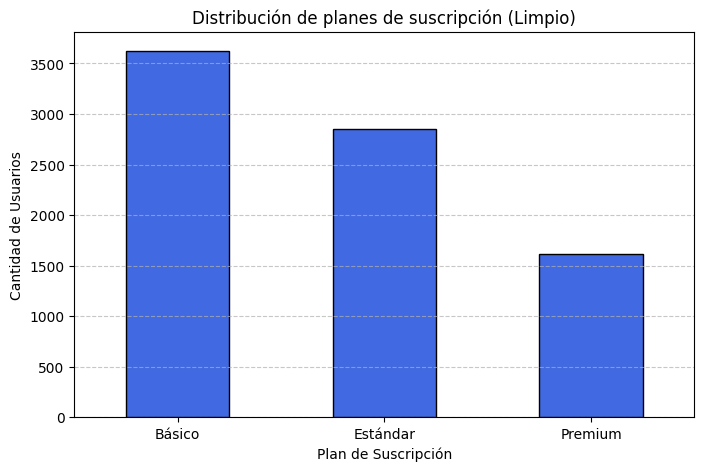

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargamos el dataset procesado
df = pd.read_csv("../data/processed/dataset_limpio.csv")

# 2. LIMPIEZA EXPRESA PARA EL EDA
# Filtramos la edad
df = df[(df["age"] >= 0) & (df["age"] <= 80)]

# Limpiamos y normalizamos los textos
df["subscription_plan"] = df["subscription_plan"].astype(str).str.strip().str.lower()
df["subscription_plan"] = df["subscription_plan"].replace({
    "basic": "Básico", "basico": "Básico", "básico": "Básico",
    "premium": "Premium", "premiun": "Premium", "pro": "Pro",
    "estándar": "Estándar", "estandar": "Estándar", "standard": "Estándar", "std": "Estándar"
})

# =========================================================
# 3. CÓDIGO DEL GRÁFICO (Esto es lo que faltaba para que aparezca)
# =========================================================
plt.figure(figsize=(8, 5))

# Graficamos el conteo de los planes limpios directamente
df["subscription_plan"].value_counts().plot(kind="bar", color="royalblue", edgecolor="black")

# Personalizamos los textos y etiquetas
plt.title("Distribución de planes de suscripción (Limpio)")
plt.xlabel("Plan de Suscripción")
plt.ylabel("Cantidad de Usuarios")
plt.xticks(rotation=0)  # Nombres horizontales bien prolijos
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Mostramos el resultado en pantalla
plt.show()

Se observa la distribución de los planes de suscripción, permitiendo identificar cuál es el más utilizado.

 ANALISIS BIVARIADO

EDAD VS TIEMPO DE USO

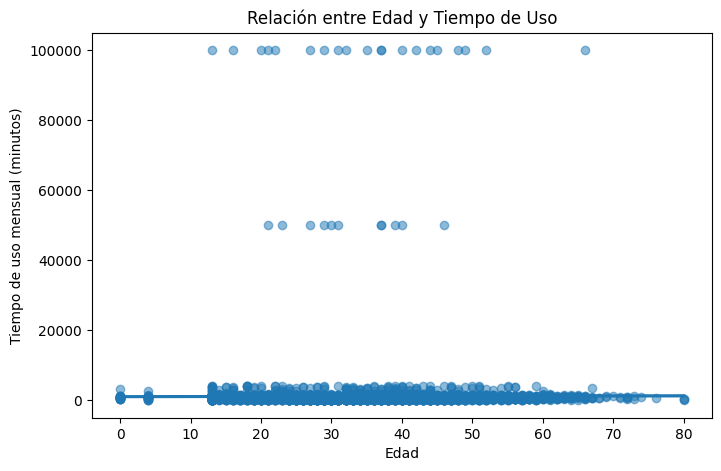

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset limpio
df = pd.read_csv("../data/processed/dataset_limpio.csv")

# Gráfico bivariado con línea de tendencia
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="age",
    y="monthly_watch_time_mins",
    scatter_kws={"alpha": 0.5}
)

plt.title("Relación entre Edad y Tiempo de Uso")
plt.xlabel("Edad")
plt.ylabel("Tiempo de uso mensual (minutos)")

plt.show()

se realizó un análisis bivariado entre la edad de los usuarios y el tiempo de visualización mensual para identificar posibles relaciones entre ambas variables.

EDAD VS GENERO FAVORITO

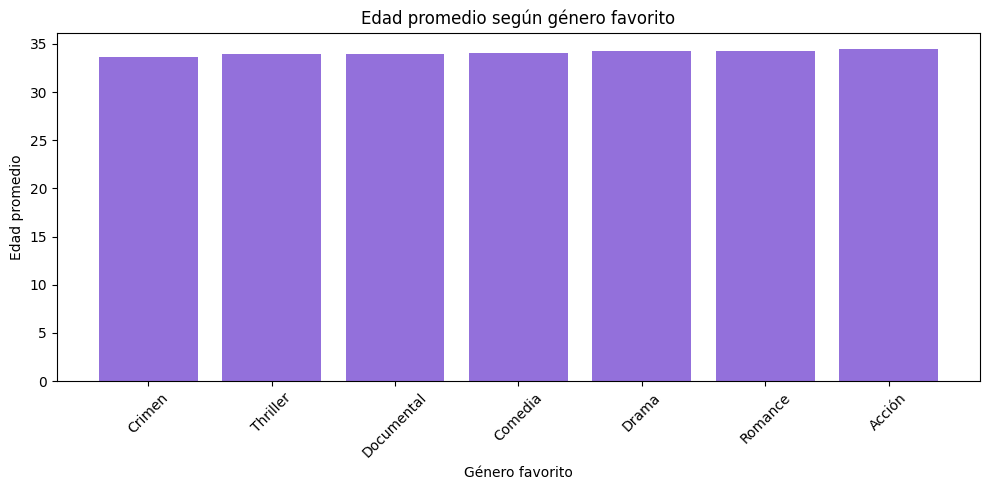

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/dataset_limpio.csv")

# Agrupar edad promedio por género
edad_genero = df.groupby("favorite_genre")["age"].mean().sort_values()

plt.figure(figsize=(10, 5))
plt.bar(edad_genero.index, edad_genero.values, color="mediumpurple")

plt.title("Edad promedio según género favorito")
plt.xlabel("Género favorito")
plt.ylabel("Edad promedio")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se realizó un análisis bivariado entre el género favorito y la edad promedio de los usuarios, con el objetivo de identificar diferencias de edad según preferencias de contenido.

MULTIVARIADO

El análisis multivariado permite identificar relaciones entre variables numéricas y su grado de correlación dentro del dataset.

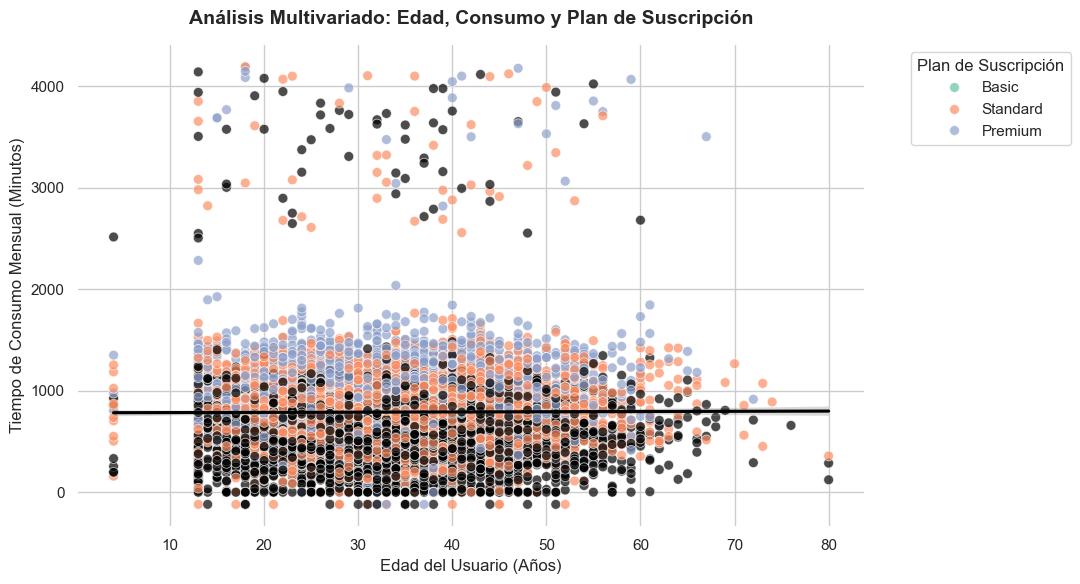

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. CARGA DE DATOS
# =========================
df = pd.read_csv("../data/processed/dataset_limpio.csv")

# =========================
# 2. COPIA DE TRABAJO
# =========================
df_multilimpio = df.copy()

# =========================
# 3. LIMPIEZA DE PLANES
# =========================
df_multilimpio["subscription_plan"] = (
    df_multilimpio["subscription_plan"]
    .astype(str)
    .str.lower()
    .str.strip()
)

mapeo_planes = {
    "standard": "Standard",
    "std": "Standard",
    "estandar": "Standard",
    "basic": "Basic",
    "basico": "Basic",
    "premium": "Premium",
    "premiun": "Premium",
}

df_multilimpio["subscription_plan"] = (
    df_multilimpio["subscription_plan"]
    .map(mapeo_planes)
    .fillna(df_multilimpio["subscription_plan"])
)

# =========================
# 4. FILTRO DE DATOS
# =========================
df_multilimpio = df_multilimpio[
    (df_multilimpio["age"] > 0)
    & (df_multilimpio["age"] <= 90)
    & (df_multilimpio["monthly_watch_time_mins"] < 10000)
    & (df_multilimpio["subscription_plan"].notna())
]

# =========================
# 5. GRAFICO MULTIVARIADO
# =========================
plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")

order = ["Basic", "Standard", "Premium"]

sns.scatterplot(
    data=df_multilimpio,
    x="age",
    y="monthly_watch_time_mins",
    hue="subscription_plan",
    hue_order=order,
    palette="Set2",
    alpha=0.7,
    s=50,
)

# Línea de tendencia general
sns.regplot(
    data=df_multilimpio,
    x="age",
    y="monthly_watch_time_mins",
    scatter=False,
    color="black"
)

# =========================
# 6. PERSONALIZACIÓN
# =========================
plt.title(
    "Análisis Multivariado: Edad, Consumo y Plan de Suscripción",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Edad del Usuario (Años)")
plt.ylabel("Tiempo de Consumo Mensual (Minutos)")

plt.legend(title="Plan de Suscripción", bbox_to_anchor=(1.05, 1), loc="upper left")

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Se realizó un análisis multivariado entre la edad, el tiempo de visualización mensual y el tipo de plan de suscripción. Esto permitió observar cómo se distribuye el consumo de contenido según la edad de los usuarios y su plan contratado, identificando posibles patrones de comportamiento diferenciados.

CONCLUSION
Durante el análisis exploratorio de datos (EDA) se identificaron patrones importantes en el comportamiento de los usuarios. Se observaron diferencias en la distribución de edades, países y planes de suscripción, así como inconsistencias iniciales en los datos que fueron posteriormente corregidas.
El EDA permitió comprender la estructura del dataset, detectar valores atípicos y preparar la información para análisis más avanzados.